In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy.optimize import curve_fit
from shapely.geometry import LineString
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from scipy.optimize import minimize
from matplotlib.transforms import Affine2D
import scipy.special as sc

In [3]:
def DoubleEscapeSort(dataframe):
    # dataframe = dataframe.drop('10', axis=1)

    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)

    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if 506<= dataframe3.iloc[i,9][1]< 516 and 506<= dataframe3.iloc[i,9][0]< 516:
            rid3.append(i)

    dataframe3_double = dataframe3[dataframe3.index.isin(rid3)]
    # dataframe3_2100['Neighbors']=dataframe3_2100['Neighbors'].apply(ast.literal_eval)
    # dataframe3_2100['ChannelV']=dataframe3_2100['ChannelV'].apply(ast.literal_eval)
    dataframe3_double=dataframe3_double.reset_index(drop=True)
    return dataframe3_double

def NTD_Sort(dataframe3_double):
    NTD_data = []

    for i in range(len(dataframe3_double)):
        for j in range(len(dataframe3_double.iloc[i,10])):
            if dataframe3_double.iloc[i,10][j] in dataframe3_double.iloc[i,15]:
                NTD_data.append(i) 

    NTD_data = dataframe3_double[dataframe3_double.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    no_NTD_data = []

    for i in range(len(dataframe3_double)):
        for j in range(len(dataframe3_double.iloc[i,10])):
            if dataframe3_double.iloc[i,10][0] and dataframe3_double.iloc[i,10][1] and dataframe3_double.iloc[i,10][2] not in dataframe3_double.iloc[i,15]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe3_double[dataframe3_double.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0] + dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return total_2100, total_511

In [4]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
# dataframe_1tonne = dataframe_1tonne[dataframe_1tonne['Dataset'] <= 3815]
dataframe = dataframe.drop('Unnamed: 0', axis=1)
col = dataframe.pop("EnergyV")
dataframe.insert(9, col.name, col)
col2 = dataframe.pop("Neighbors")
dataframe.insert(14, col2.name, col2)
col3 = dataframe.pop("NTD")
dataframe.insert(15, col3.name, col3)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_1495/376053419.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)


In [5]:
dataframe_double = DoubleEscapeSort(dataframe)

NTD_double, no_NTD_double = NTD_Sort(dataframe_double)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_double)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_double)

NTD_1600, NTD_1022 = PrimarySecondarySplit(NTD_double)
nonNTD_1600, nonNTD_1022 = PrimarySecondarySplit(no_NTD_double)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_1495/580875600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_1495/580875600.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_1495/580875600.py:7: SettingWithCopyWarning: 
A value is trying

In [53]:
def NormGuassianLinear(x,mu,sigma, A,f, E0, E1):
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+f*p

def NegLogLikelihoodGuassLinear(params,data):
    mu,sigma, A,f = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianLinear(np.asarray(data),mu,sigma,A,f, E0, E1)
    x = x[x>0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLikelihoodGuassLinear(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLikelihoodGuassLinear, initial_params, args=(data),
                      method='Nelder-Mead', bounds=[(0, None), (0, None),(-bound_A, bound_A) ,(0,1)])
    return result.x

def Chi2(data, arr):
    mu, sigma, A, f = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianLinear(filtered_bin_centers, mu, sigma, A, f, E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Graph(data, arr):
    mu_fit, sigma_fit, A_fit, f_fit = arr
    
    x_values = np.linspace(min(data), max(data), 1000)
    bin_num = int(max(data) - min(data))
    bin_width = (max(data) - min(data))/bin_num
    
    fitted_pdf = NormGuassianLinear(x_values, mu_fit, sigma_fit, A_fit, f_fit, min(x_values), max(x_values))*len(data)*bin_width
    linear = (f_fit*(1+A_fit*(x_values-((min(data)+max(data))/2)))/(max(data)-min(data)))*len(data)*bin_width
    guass = (1-f_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(data)*bin_width
    
    return x_values, fitted_pdf, linear, guass

def Residual_Plot(data, arr):
    mu,sigma, A,f = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianLinear(filtered_bin_centers, mu, sigma, A, f, E0, E1)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

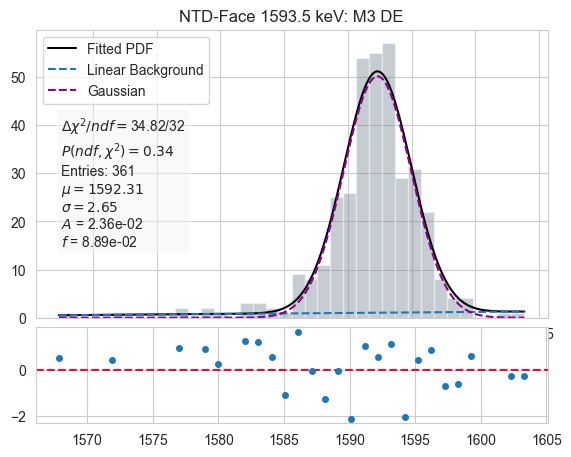

In [62]:
mu = 1591.8792014690118
sigma = 2.555497630284129
A = 0.003
f = 0.5
initial_parms = [mu, sigma, A, f]
data_fits = MinimizeNegLogLikelihoodGuassLinear(NTD_1600, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values, fitted_pdf, linear, guass = Graph(NTD_1600, data_fits)

bin_num = int(max(NTD_1600) - min(NTD_1600))

bin_width = (max(NTD_1600) - min(NTD_1600))/bin_num

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(NTD_1600, data_fits), decimals=2)) +'/' +str(bin_num - 4, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num-4, Chi2(NTD_1600, data_fits)), ),
    'Entries: ' + (str(len(NTD_1600))),
    r'$\mu=%.2f$' % (data_fits[0], ),
    r'$\sigma=%.2f$' % (data_fits[1], ),
    r'$A$ = ' + str(np.format_float_scientific(data_fits[2], precision = 2), ),
    r'$f$ = ' + str(np.format_float_scientific(data_fits[3], precision = 2),)
    ))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values,linear, label='Linear Background', linestyle='--')
ax.plot(x_values, guass, label = 'Gaussian', linestyle='--', color='darkmagenta')

ax.hist(NTD_1600, bins = bin_num , color='slategray', alpha=0.4)
ax.text(0.05, 0.70, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 1593.5 keV: M3 DE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(NTD_1600, data_fits)[0],Residual_Plot(NTD_1600, data_fits)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

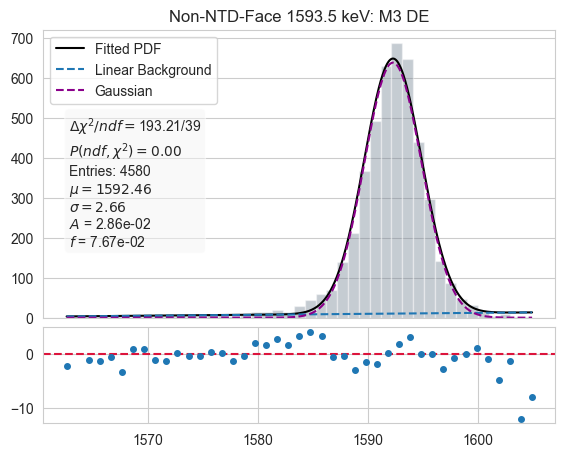

In [91]:
muNonNTD = 1591.8792014690118
sigmaNonNTD = 2.555497630284129
ANonNTD = 0.005
fNonNTD = 0.5
initial_parms = [muNonNTD, sigmaNonNTD, ANonNTD, fNonNTD]
NonNTD_fit = MinimizeNegLogLikelihoodGuassLinear(nonNTD_1600, initial_parms)
# print(f"Fitted parameters: {fitted_params}")

x_values, fitted_pdf, linear, guass = Graph(nonNTD_1600, NonNTD_fit )

bin_num = int(max(nonNTD_1600) - min(nonNTD_1600))

bin_width = (max(nonNTD_1600) - min(nonNTD_1600))/bin_num

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(nonNTD_1600, NonNTD_fit), decimals=2)) +'/' +str(bin_num - 4, ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(int(max(nonNTD_1600) - min(nonNTD_1600)) - 4, Chi2(nonNTD_1600, NonNTD_fit)), ),
    'Entries: ' + (str(len(nonNTD_1600))),
    r'$\mu=%.2f$' % (NonNTD_fit[0], ),
    r'$\sigma=%.2f$' % (NonNTD_fit[1], ),
    r'$A$ = ' + str(np.format_float_scientific(NonNTD_fit[2], precision = 2), ),
    r'$f$ = ' + str(np.format_float_scientific(NonNTD_fit[3], precision = 2),)
    ))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values, linear, label='Linear Background', linestyle='--')
ax.plot(x_values, guass, label = 'Gaussian', linestyle='--', color='darkmagenta')

ax.hist(nonNTD_1600, bins = bin_num , color='slategray', alpha=0.4)
ax.text(0.05, 0.7, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 1593.5 keV: M3 DE')
ax.set_xticks([])
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(nonNTD_1600, NonNTD_fit)[0],Residual_Plot(nonNTD_1600, NonNTD_fit)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

In [65]:
FC_1600, FC_1022 = PrimarySecondarySplit(FC)
CE_1600, CE_1022 = PrimarySecondarySplit(CE)
NC_1600, NC_1022 = PrimarySecondarySplit(NC)
FN_1600, FN_1022 = PrimarySecondarySplit(FN)
NE_1600, NE_1022 = PrimarySecondarySplit(NE)
FF_1600, FF_1022 = PrimarySecondarySplit(FF)
CC_1600, CC_1022 = PrimarySecondarySplit(CC)
EE_1600, EE_1022 = PrimarySecondarySplit(EE)
NN_1600, NN_1022 = PrimarySecondarySplit(NN)
FE_1600, FE_1022 = PrimarySecondarySplit(FE)

FC_1600NTD, FC_1022NTD = PrimarySecondarySplit(FC_NTD)
FN_1600NTD, FN_1022NTD = PrimarySecondarySplit(FN_NTD)
FF_1600NTD, FF_1022NTD = PrimarySecondarySplit(FF_NTD)
FE_1600NTD, FE_1022NTD = PrimarySecondarySplit(FE_NTD)

FC_initial_1600 = [1593.040673301979, 2.3171847521755162, 0.005, 0.5]
CE_initial_1600 = [1592.5128906848684, 1.8512685822217934, 0.005, 0.5]
NC_initial_1600 = [1593.3113489749808, 2.4615818104711433, 0.005, 0.5]
FN_initial_1600 = [1592.9010460464792, 2.536260729120265, 0.005, 0.5]
NE_initial_1600 = [1592.7815392527868, 2.888842503381022, 0.005, 0.5]
FF_initial_1600 = [1592.7040670348363, 2.660575293091914, 0.005, 0.5]
EE_initial_1600= [1592.4316756890375, 2.4769928244708357, 0.005, 0.5]
NN_initial_1600= [1592.6555876876398, 2.6052131244724173, 0.005, 0.5]
FE_initial_1600= [1592.603239086126, 2.655431371739795, 0.005, 0.5]
CC_initial_1600= [np.mean(CC_1600), np.std(CC_1600), 0.005, 0.5]

FCarr = MinimizeNegLogLikelihoodGuassLinear(FC_1600, FC_initial_1600)
CEarr = MinimizeNegLogLikelihoodGuassLinear(CE_1600, CE_initial_1600)
NCarr = MinimizeNegLogLikelihoodGuassLinear(NC_1600, NC_initial_1600)
FNarr = MinimizeNegLogLikelihoodGuassLinear(FN_1600, FN_initial_1600)
NEarr = MinimizeNegLogLikelihoodGuassLinear(NE_1600, NE_initial_1600)
FFarr = MinimizeNegLogLikelihoodGuassLinear(FF_1600, FF_initial_1600)
EEarr= MinimizeNegLogLikelihoodGuassLinear(EE_1600, EE_initial_1600)
NNarr = MinimizeNegLogLikelihoodGuassLinear(NN_1600, NN_initial_1600)
FEarr = MinimizeNegLogLikelihoodGuassLinear(FE_1600, FE_initial_1600)
CCarr = MinimizeNegLogLikelihoodGuassLinear(CC_1600, CC_initial_1600)

# FC_initial_1600NTD = [1593.040673301979, 2.3171847521755162, 0.05, 0.5]
# FF_initial_1600NTD = [1592.7040670348363, 2.660575293091914, 0.05, 0.5]
# FE_initial_1600NTD= [1592.603239086126, 2.655431371739795, 0.05, 0.5]
# FN_initial_1600NTD = [1592.9010460464792, 2.536260729120265, 0.05, 0.5]

FCNTDarr = MinimizeNegLogLikelihoodGuassLinear(FC_1600NTD, FC_initial_1600)
FNNTDarr = MinimizeNegLogLikelihoodGuassLinear(FN_1600NTD, FN_initial_1600)
FFNTDarr = MinimizeNegLogLikelihoodGuassLinear(FF_1600NTD, FF_initial_1600)
FENTDarr = MinimizeNegLogLikelihoodGuassLinear(FE_1600NTD, FE_initial_1600)

In [88]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def TopologyPlots(hist_data, initial_parms, topologies, cols, rows):
    bin_num = []
    xvals = []
    chi2s = []
    fitvals = []
    guassvals = []
    linearvals = []
    
    for i in range(len(hist_data)):
        x, PDF_fit, linear, guass = Graph(hist_data[i], initial_parms[i])
        bin_num.append(int(max(hist_data[i])-min(hist_data[i])))
        xvals.append(x)
        fitvals.append(PDF_fit)
        linearvals.append(linear)
        guassvals.append(guass)
        
        chi2s.append(Chi2(hist_data[i], initial_parms[i]))
    
    pvals = []
    
    for j in range(len(chi2s)):
        pvals.append(PValue(bin_num[j],chi2s[j]))
    
    means = []
    sigmas = []
    As =[]
    fs = []
    
    for i in range(len(initial_parms)):
        means.append(initial_parms[i][0])
        sigmas.append(initial_parms[i][1])
        As.append(initial_parms[i][2])
        fs.append(initial_parms[i][3])
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': hist_data,
        'X-axis': xvals,
        'Fit': fitvals,
        'Linear': linearvals,
        'Guass': guassvals,
        'Means': means,
        'Sigmas': sigmas,
        'A': As,
        'f': fs, 
        'Chi2': chi2s,
        'p-value': pvals}
    
    df = pd.DataFrame(data)
    
    fig, axs = plt.subplots(cols, rows, figsize=(10, 15))
    props = dict(boxstyle='round', facecolor='whitesmoke')

    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) + '/' + str(df['Bin Num'][i] - 6, ),
            r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
            'Entries: ' + (str(len(df['Histogram Data'][i]))),
            r'$\mu=%.2f$' % (df['Means'][i], ),
            r'$\sigma=%.2f$' % (df['Sigmas'][i], ),
            r'$A$ = ' + str(np.format_float_scientific(df['A'][i], precision = 2), ),
            r'$f$ = ' + str(np.format_float_scientific(df['f'][i], precision = 2), )))
            
            ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], color='slategray', alpha=0.4)
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='black')
            ax.plot(df['X-axis'][i], df['Linear'][i], label='Linear Bckg', linestyle='--', color='purple')
            ax.plot(df['X-axis'][i], df['Guass'][i], label='Gaussian', linestyle='--', color='blue')
            ax.set_title(df["Topologies"][i])
            ax.legend(fontsize = 8, loc='upper right')
            ax.set_xticks([])
            
            ax2 = divider.append_axes("bottom", size="40%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(hist_data[i], initial_parms[i])[0],Residual_Plot(hist_data[i], initial_parms[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()

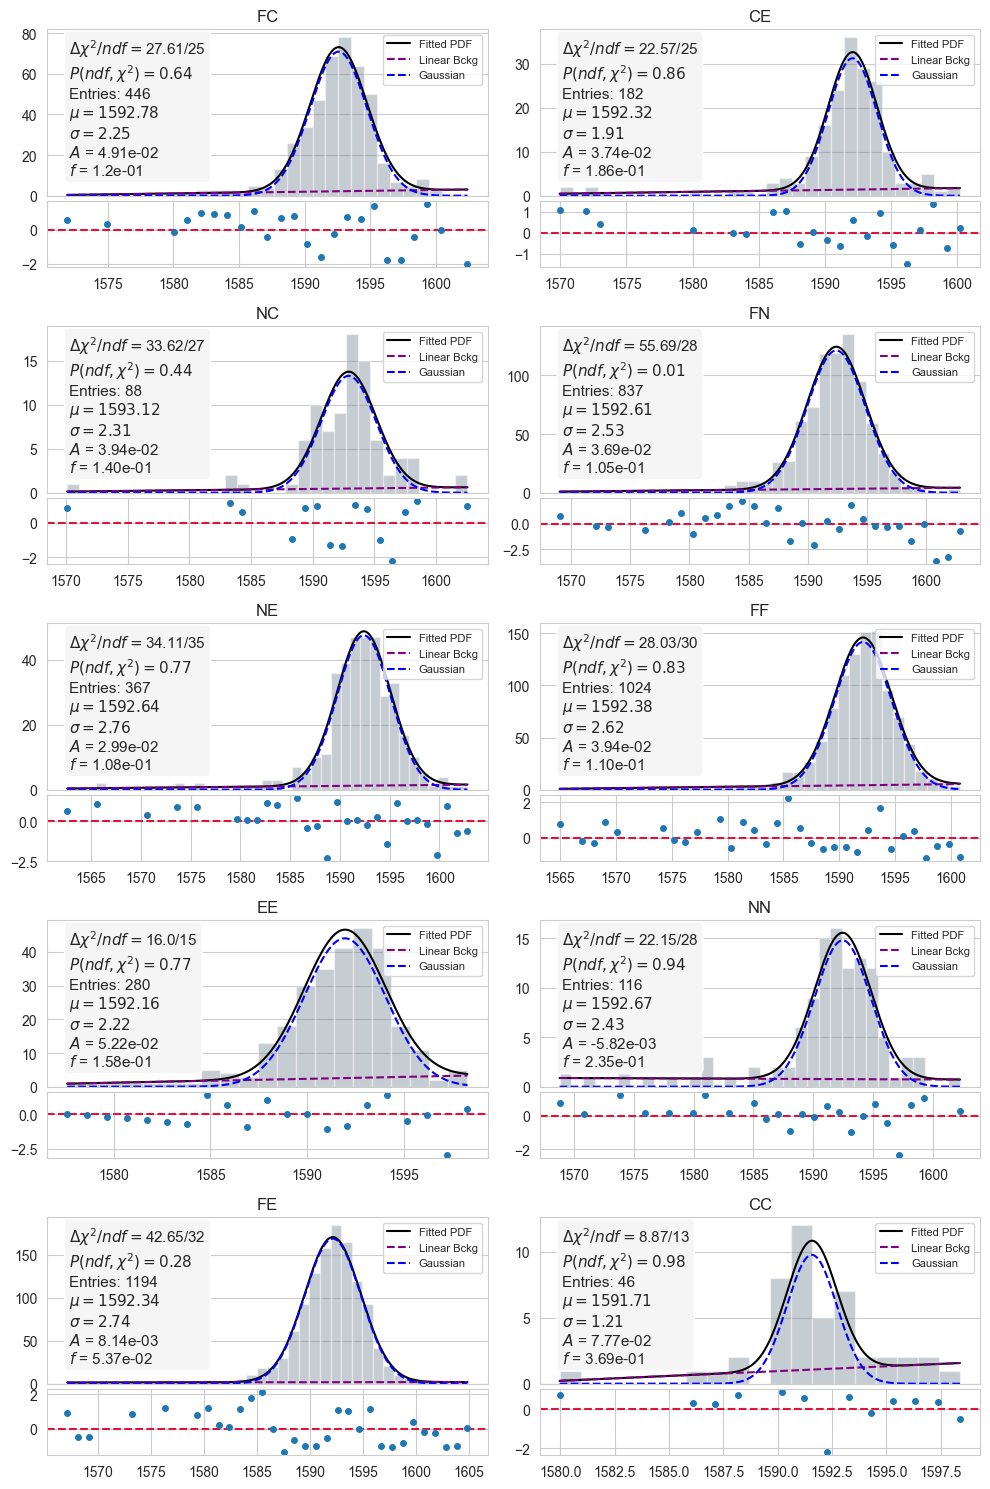

In [89]:
hist_data = [FC_1600, CE_1600, NC_1600, FN_1600, NE_1600, FF_1600, EE_1600, NN_1600, FE_1600, CC_1600]
initial_parms = [FCarr, CEarr, NCarr, FNarr, NEarr, FFarr, EEarr, NNarr, FEarr, CCarr]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

TopologyPlots(hist_data, initial_parms, topologies,5,2)

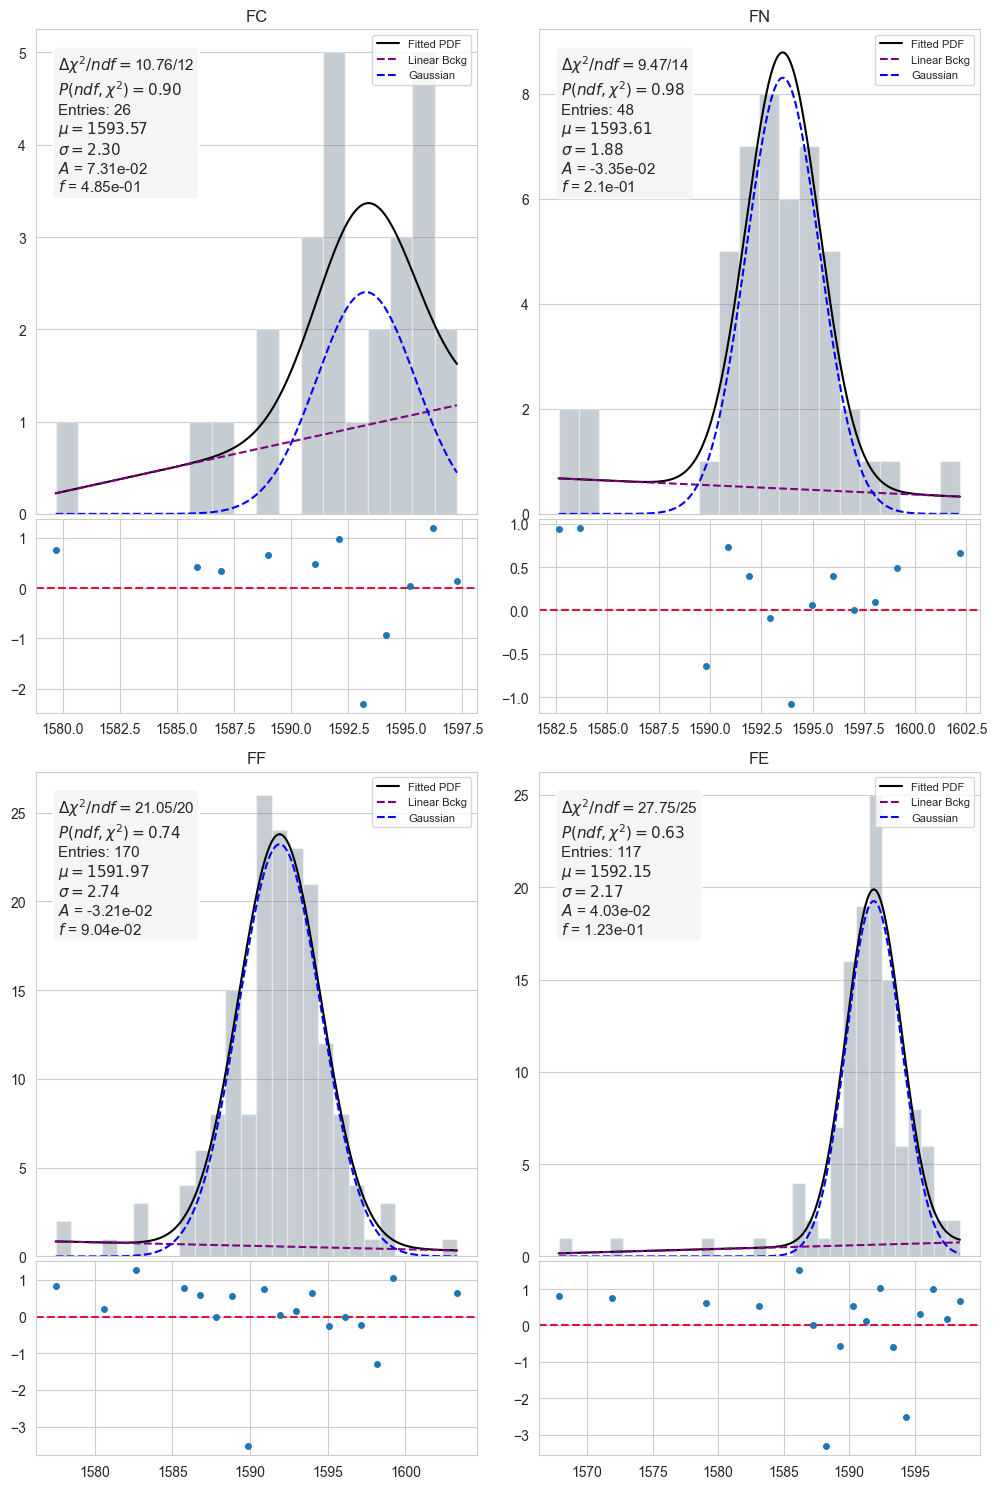

In [90]:
hist_data = [FC_1600NTD, FN_1600NTD, FF_1600NTD, FE_1600NTD]
initial_parms = [FCNTDarr, FNNTDarr, FFNTDarr, FENTDarr]
topologies = ['FC', 'FN', 'FF','FE']

TopologyPlots(hist_data, initial_parms, topologies,2,2)

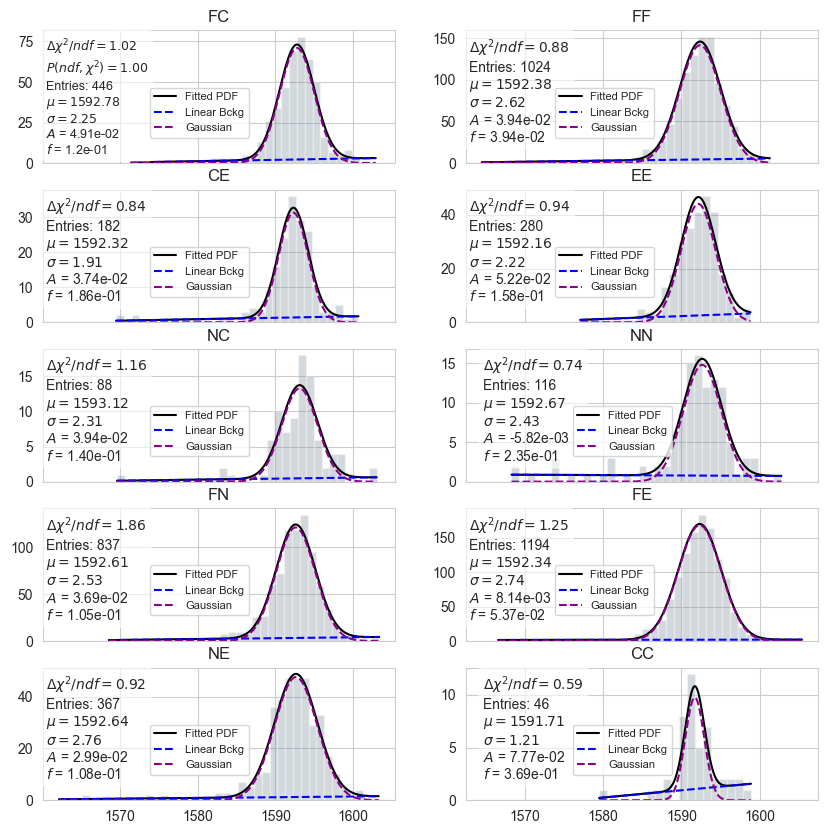

In [20]:
fig, ax = plt.subplots(5,2, sharex='col', figsize=(10, 10))
# fig.text(0.04, 0.6, 'Energy (keV)', va='center', rotation = 'vertical')
# fig.text(0.6, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.6)
# fig.suptitle('Non-NTD Face 2104 keV Topology Fits')

textFC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FCchi2/(int(max(FC_1600) - min(FC_1600)) - 4), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (sc.gammainc(4/2, FCchi2/2), ),
    'Entries: ' + (str(len(FC_1600))),
    r'$\mu=%.2f$' % (FCmu_fit, ),
    r'$\sigma=%.2f$' % (FCsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FCA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FCf_fit, precision = 2), )))

ax[0,0].plot(FCx, FC_fit,label='Fitted PDF', color='black')
ax[0,0].hist(FC_1600, bins = int(max(FC_1600)-min(FC_1600)) , alpha=0.3, color='slategrey')
ax[0,0].plot(FCx, FClinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[0,0].plot(FCx, FCguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[0,0].text(0.01, 0.95, textFC, transform=ax[0,0].transAxes, fontsize=9,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
ax[0,0].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))
##############
textCE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (CEchi2/(int(max(CE_1600) - min(CE_1600)) - 4), ),
    'Entries: ' + (str(len(CE_1600))),
    r'$\mu=%.2f$' % (CEmu_fit, ),
    r'$\sigma=%.2f$' % (CEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(CEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(CEf_fit, precision = 2), )))

ax[1,0].plot(CEx, CE_fit, color='black', label='Fitted PDF')
ax[1,0].plot(CEx, CElinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[1,0].plot(CEx, CEguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[1,0].hist(CE_1600, bins = int(max(CE_1600)-min(CE_1600)) , alpha=0.3, color='slategrey')
ax[1,0].text(0.01, 0.95, textCE, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('CE')
ax[1,0].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))
#######
textNC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (NCchi2/(int(max(NC_1600) - min(NC_1600)) - 4), ),
    'Entries: ' + (str(len(NC_1600))),
    r'$\mu=%.2f$' % (NCmu_fit, ),
    r'$\sigma=%.2f$' % (NCsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NCA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NCf_fit, precision = 2), )))

ax[2,0].plot(NCx, NC_fit, color='black', label='Fitted PDF')
ax[2,0].plot(NCx, NClinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[2,0].plot(NCx, NCguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[2,0].hist(NC_1600, bins = int(max(NC_1600)-min(NC_1600)) , alpha=0.3, color='slategrey')
ax[2,0].text(0.01, 0.95, textNC, transform=ax[2,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,0].set_title('NC')
ax[2,0].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))

########
textFN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FNchi2/(int(max(FN_1600) - min(FN_1600)) - 4), ),
    'Entries: ' + (str(len(FN_1600))),
    r'$\mu=%.2f$' % (FNmu_fit, ),
    r'$\sigma=%.2f$' % (FNsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FNA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FNf_fit, precision = 2), )))

ax[3,0].plot(FNx, FN_fit, color='black', label='Fitted PDF')
ax[3,0].plot(FNx, FNlinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[3,0].plot(FNx, FNguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[3,0].hist(FN_1600, bins = int(max(FN_1600)-min(FN_1600)) , alpha=0.3, color='slategrey')
ax[3,0].text(0.01, 0.95, textFN, transform=ax[3,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[3,0].set_title('FN')
ax[3,0].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))

########
textNE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (NEchi2/(int(max(NE_1600) - min(NE_1600)) - 4), ),
    'Entries: ' + (str(len(NE_1600))),
    r'$\mu=%.2f$' % (NEmu_fit, ),
    r'$\sigma=%.2f$' % (NEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NEf_fit, precision = 2), )))

ax[4,0].plot(NEx, NE_fit, color='black', label='Fitted PDF')
ax[4,0].plot(NEx, NElinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[4,0].plot(NEx, NEguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[4,0].hist(NE_1600, bins = int(max(NE_1600)-min(NE_1600)) , alpha=0.3, color='slategrey')
ax[4,0].text(0.01, 0.95, textNE, transform=ax[4,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[4,0].set_title('NE')
ax[4,0].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))

########
textFF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FFchi2/(int(max(FF_1600) - min(FF_1600)) - 4), ),
    'Entries: ' + (str(len(FF_1600))),
    r'$\mu=%.2f$' % (FFmu_fit, ),
    r'$\sigma=%.2f$' % (FFsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FFA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FFA_fit, precision = 2), )))

ax[0,1].plot(FFx, FF_fit, color='black', label='Fitted PDF')
ax[0,1].plot(FFx, FFlinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[0,1].plot(FFx, FFguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[0,1].hist(FF_1600, bins = int(max(FF_1600)-min(FF_1600)) , alpha=0.3, color='slategrey')
ax[0,1].text(0.01, 0.95, textFF, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FF')
ax[0,1].legend(fontsize = 8, bbox_to_anchor=(0.55,0.15))
########
textEE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (EEchi2/(int(max(EE_1600) - min(EE_1600)) - 4), ),
    'Entries: ' + (str(len(EE_1600))),
    r'$\mu=%.2f$' % (EEmu_fit, ),
    r'$\sigma=%.2f$' % (EEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(EEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(EEf_fit, precision = 2), )))

ax[1,1].plot(EEx, EE_fit, color='black', label='Fitted PDF')
ax[1,1].plot(EEx, EElinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[1,1].plot(EEx, EEguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[1,1].hist(EE_1600, bins = int(max(EE_1600)-min(EE_1600)) , alpha=0.3, color='slategrey')
ax[1,1].text(0.01, 0.95, textEE, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('EE')
ax[1,1].legend(fontsize = 8, bbox_to_anchor=(0.55,0.15))

########
textNN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (NNchi2/(int(max(NN_1600) - min(NN_1600)) - 4), ),
    'Entries: ' + (str(len(NN_1600))),
    r'$\mu=%.2f$' % (NNmu_fit, ),
    r'$\sigma=%.2f$' % (NNsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NNA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NNf_fit, precision = 2), )))

ax[2,1].plot(NNx, NN_fit, color='black', label='Fitted PDF')
ax[2,1].plot(NNx, NNlinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[2,1].plot(NNx, NNguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[2,1].hist(NN_1600, bins = int(max(NN_1600)-min(NN_1600)) , alpha=0.3, color='slategrey')
ax[2,1].text(0.05, 0.95, textNN, transform=ax[2,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,1].set_title('NN')
ax[2,1].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))

########
textFE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FEchi2/(int(max(FE_1600) - min(FE_1600)) - 4), ),
    'Entries: ' + (str(len(FE_1600))),
    r'$\mu=%.2f$' % (FEmu_fit, ),
    r'$\sigma=%.2f$' % (FEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FEf_fit, precision = 2), )))

ax[3,1].plot(FEx, FE_fit, color='black', label='Fitted PDF')
ax[3,1].plot(FEx, FElinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[3,1].plot(FEx, FEguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[3,1].hist(FE_1600, bins = int(max(FE_1600)-min(FE_1600)), alpha=0.3, color='slategrey')
ax[3,1].text(0.01, 0.95, textFE, transform=ax[3,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[3,1].set_title('FE')
ax[3,1].legend(fontsize = 8, bbox_to_anchor=(0.55,0.15))
#########
textCC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (CCchi2/(int(max(CC_1600) - min(CC_1600)) - 4), ),
    'Entries: ' + (str(len(CC_1600))),
    r'$\mu=%.2f$' % (CCmu_fit, ),
    r'$\sigma=%.2f$' % (CCsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(CCA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(CCf_fit, precision = 2), )))

ax[4,1].plot(CCx, CC_fit, color='black', label='Fitted PDF')
ax[4,1].plot(CCx, CClinear, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[4,1].plot(CCx, CCguass, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[4,1].hist(CC_1600, bins = int(max(CC_1600)-min(CC_1600)) , alpha=0.3, color='slategrey')
ax[4,1].text(0.05, 0.95, textCC, transform=ax[4,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[4,1].set_title('CC')
ax[4,1].legend(fontsize = 8, bbox_to_anchor=(0.6,0.15))

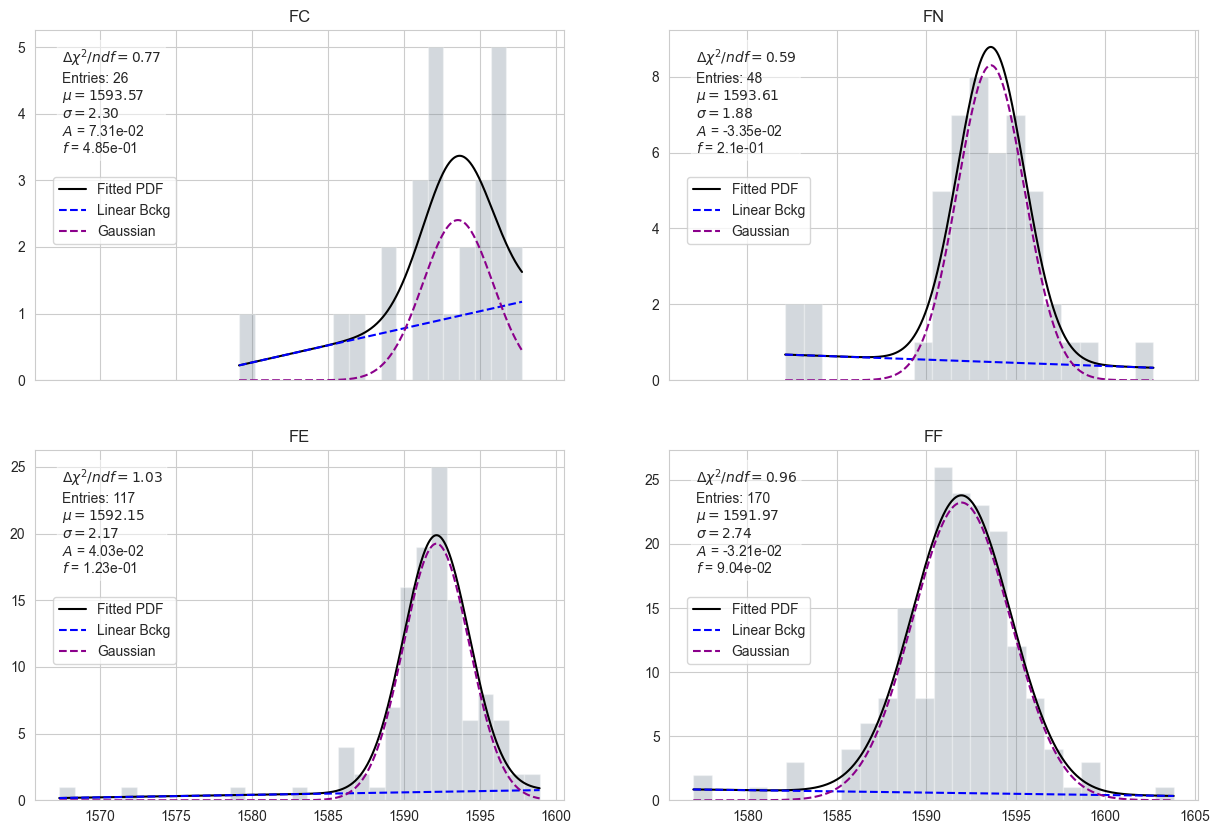

In [149]:
fig, ax = plt.subplots(2,2, sharex='col', figsize=(15, 10))
# fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# fig.suptitle('NTD Face 2104 keV Topology Fits')

textFCNTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FCchi2NTD/(int(max(FC_1600NTD) - min(FC_1600NTD)) - 4), ),
    'Entries: ' + (str(len(FC_1600NTD))),
    r'$\mu=%.2f$' % (FCmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FCsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FCA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FCf_fitNTD, precision = 2), )))

ax[0,0].plot(FCxNTD, FC_fitNTD,label='Fitted PDF', color='black')
ax[0,0].plot(FCxNTD, FClinearNTD, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[0,0].plot(FCxNTD, FCguassNTD, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[0,0].hist(FC_1600NTD, int(max(FC_1600NTD)-min(FC_1600NTD)) , alpha=0.3, color='slategrey')
ax[0,0].text(0.05, 0.95, textFCNTD, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
ax[0,0].legend(bbox_to_anchor=(0.28,0.6))

##############

textFNNTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FNchi2NTD/(int(max(FN_1600NTD) - min(FN_1600NTD)) - 4), ),
    'Entries: ' + (str(len(FN_1600NTD))),
    r'$\mu=%.2f$' % (FNmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FNsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FNA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FNf_fitNTD, precision = 2), )))

ax[0,1].plot(FNxNTD, FN_fitNTD, color='black', label='Fitted PDF')
ax[0,1].plot(FNxNTD, FNlinearNTD, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[0,1].plot(FNxNTD, FNguassNTD, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[0,1].hist(FN_1600NTD, bins = int(max(FN_1600NTD)-min(FN_1600NTD)) , alpha=0.3, color='slategrey')
ax[0,1].text(0.05, 0.95, textFNNTD, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FN')
ax[0,1].legend(bbox_to_anchor=(0.28,0.6))

########
textFFNTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FFchi2NTD/(int(max(FF_1600NTD) - min(FF_1600NTD)) - 4), ),
    'Entries: ' + (str(len(FF_1600NTD))),
    r'$\mu=%.2f$' % (FFmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FFsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FFA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FFf_fitNTD, precision = 2), )))

ax[1,1].plot(FFxNTD, FF_fitNTD, color='black', label='Fitted PDF')
ax[1,1].plot(FFxNTD, FFlinearNTD, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[1,1].plot(FFxNTD, FFguassNTD, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[1,1].hist(FF_1600NTD, bins = int(max(FF_1600NTD)-min(FF_1600NTD)) , alpha=0.3, color='slategrey')
ax[1,1].text(0.05, 0.95, textFFNTD, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('FF')
ax[1,1].legend(bbox_to_anchor=(0.28,0.6))

#########
textFENTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (FEchi2NTD/(int(max(FE_1600NTD) - min(FE_1600NTD)) - 4), ),
    'Entries: ' + (str(len(FE_1600NTD))),
    r'$\mu=%.2f$' % (FEmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FEsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FEA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FEf_fitNTD, precision = 2), )))

ax[1,0].plot(FExNTD, FE_fitNTD, color='black', label='Fitted PDF')
ax[1,0].plot(FExNTD, FElinearNTD, label='Linear Bckg', color = 'blue', linestyle = '--')
ax[1,0].plot(FExNTD, FEguassNTD, label = 'Gaussian', color='darkmagenta', linestyle = '--')

ax[1,0].hist(FE_1600NTD, bins = int(max(FE_1600NTD)-min(FE_1600NTD)), alpha=0.3, color='slategrey')
ax[1,0].text(0.05, 0.95, textFENTD, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('FE')
ax[1,0].legend(bbox_to_anchor=(0.28,0.6))

In [27]:
def NegLogLikelihoodGuassExp(params,data):
    mu,sigma, A, f = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianLinear(k,mu,sigma,A,f, E0, E1)
        # if x > 0:
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma,A,f):
    params = [mu, sigma, A, f]
    arr1 = NegLogLikelihoodGuassExp(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
    if str(intersection) == 'LINESTRING Z EMPTY':
        intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.01))[0]
        intersection = mu[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [28]:
FCmu_arr = np.linspace(FCmu_fit-5, FCmu_fit+5, 10000) 
CEmu_arr = np.linspace(CEmu_fit-10, CEmu_fit+10, 10000) # 
NCmu_arr = np.linspace(NCmu_fit-2, NCmu_fit+2, 1000) #
FNmu_arr = np.linspace(FNmu_fit-5, FNmu_fit+5, 1000)
NEmu_arr = np.linspace(NEmu_fit-10, NEmu_fit+10, 10000)
FFmu_arr = np.linspace(FFmu_fit-5, FFmu_fit+5, 1000)
EEmu_arr = np.linspace(EEmu_fit-2, EEmu_fit+2, 1500) #
NNmu_arr = np.linspace(NNmu_fit-5, NNmu_fit+5, 2000) #
FEmu_arr = np.linspace(FEmu_fit-5, FEmu_fit+5, 1000)
CCmu_arr = np.linspace(CCmu_fit-2, CCmu_fit+2, 1400) #array

FCintersection_mu, FCerror_mu = Uncertainity(FC_1600, FCmu_arr, FCsigma_fit, FCA_fit, FCf_fit)
CEintersection_mu, CEerror_mu = Uncertainity(CE_1600, CEmu_arr, CEsigma_fit, CEA_fit, CEf_fit)
NCintersection_mu, NCerror_mu = Uncertainity(NC_1600, NCmu_arr, NCsigma_fit, NCA_fit, NCf_fit)
FNintersection_mu, FNerror_mu = Uncertainity(FN_1600, FNmu_arr, FNsigma_fit, FNA_fit, FNf_fit)
NEintersection_mu, NEerror_mu = Uncertainity(NE_1600, NEmu_arr, NEsigma_fit, NEA_fit, NEf_fit)
FFintersection_mu, FFerror_mu = Uncertainity(FF_1600, FFmu_arr, FFsigma_fit, FFA_fit, FFf_fit) 
EEintersection_mu, EEerror_mu = Uncertainity(EE_1600, EEmu_arr, EEsigma_fit, EEA_fit, EEf_fit)
NNintersection_mu, NNerror_mu = Uncertainity(NN_1600, NNmu_arr, NNsigma_fit, NNA_fit, NNf_fit) 
FEintersection_mu, FEerror_mu = Uncertainity(FE_1600, FEmu_arr, FEsigma_fit, FEA_fit, FEf_fit)
CCintersection_mu, CCerror_mu = Uncertainity(CC_1600, CCmu_arr, CCsigma_fit, CCA_fit, CCf_fit)

In [29]:
FCsigma_arr = np.linspace(FCsigma_fit/2, FCsigma_fit*2, 100)
CEsigma_arr = np.linspace(CEsigma_fit/2, CEsigma_fit*2, 100)
NCsigma_arr = np.linspace(NCsigma_fit/2, NCsigma_fit*2, 100)
FNsigma_arr = np.linspace(FNsigma_fit/2, FNsigma_fit*2, 100)
NEsigma_arr = np.linspace(NEsigma_fit/2, NEsigma_fit*2, 100)
FFsigma_arr = np.linspace(FFsigma_fit/2, FFsigma_fit*2, 100)
EEsigma_arr = np.linspace(EEsigma_fit/2, EEsigma_fit*2, 100)
NNsigma_arr = np.linspace(NNsigma_fit/2, NNsigma_fit*2, 100)
FEsigma_arr = np.linspace(FEsigma_fit/2, FEsigma_fit*2, 100)
CCsigma_arr = np.linspace(CCsigma_fit/2, CCsigma_fit*2, 100)

FCintersection_sigma, FCerror_sigma = Uncertainity(FC_1600, FCmu_fit, FCsigma_arr, FCA_fit, FCf_fit)
CEintersection_sigma, CEerror_sigma = Uncertainity(CE_1600, CEmu_fit, CEsigma_arr, CEA_fit, CEf_fit)
NCintersection_sigma, NCerror_sigma = Uncertainity(NC_1600, NCmu_fit, NCsigma_arr, NCA_fit, NCf_fit)
FNintersection_sigma, FNerror_sigma = Uncertainity(FN_1600, FNmu_fit, FNsigma_arr, FNA_fit, FNf_fit)
NEintersection_sigma, NEerror_sigma = Uncertainity(NE_1600, NEmu_fit, NEsigma_arr, NEA_fit, NEf_fit)
FFintersection_sigma, FFerror_sigma = Uncertainity(FF_1600, FFmu_fit, FFsigma_arr, FFA_fit, FFf_fit)
EEintersection_sigma, EEerror_sigma = Uncertainity(EE_1600, EEmu_fit, EEsigma_arr, EEA_fit, EEf_fit)
CCintersection_sigma, CCerror_sigma = Uncertainity(CC_1600, CCmu_fit, CCsigma_arr, CCA_fit, CCf_fit)
NNintersection_sigma, NNerror_sigma = Uncertainity(NN_1600, NNmu_fit, NNsigma_arr, NNA_fit, NNf_fit) 
FEintersection_sigma, FEerror_sigma = Uncertainity(FE_1600, FEmu_fit, FEsigma_arr, FEA_fit, FEf_fit) 

In [30]:
FCmu_arrNTD = np.linspace(FCmu_fitNTD-5, FCmu_fitNTD+5, 1000) #array
FNmu_arrNTD = np.linspace(FNmu_fitNTD-2, FNmu_fitNTD+5, 1000) 
FFmu_arrNTD = np.linspace(FFmu_fitNTD-1, FFmu_fitNTD+1, 1500)
FEmu_arrNTD = np.linspace(FEmu_fitNTD-5, FEmu_fitNTD+5, 4000)

FCintersection_muNTD, FCerror_muNTD = Uncertainity(FC_1600NTD, FCmu_arrNTD, FCsigma_fitNTD, FCA_fitNTD, FCf_fitNTD)
FNintersection_muNTD, FNerror_muNTD = Uncertainity(FN_1600NTD, FNmu_arrNTD, FNsigma_fitNTD, FNA_fitNTD, FNf_fitNTD)
FFintersection_muNTD, FFerror_muNTD = Uncertainity(FF_1600NTD, FFmu_arrNTD, FFsigma_fitNTD, FFA_fitNTD, FFf_fitNTD) 
FEintersection_muNTD, FEerror_muNTD = Uncertainity(FE_1600NTD, FEmu_arrNTD, FEsigma_fitNTD, FEA_fitNTD, FEf_fitNTD)

In [112]:
print(FEintersection_muNTD)

[1591.91355254 1592.39617319]


In [31]:
FCsigma_arrNTD = np.linspace(FCsigma_fitNTD/2, FCsigma_fitNTD*2, 100)
FNsigma_arrNTD = np.linspace(FNsigma_fitNTD/2, FNsigma_fitNTD*2, 100)
FFsigma_arrNTD = np.linspace(FFsigma_fitNTD/2, FFsigma_fitNTD*2, 100)
FEsigma_arrNTD = np.linspace(FEsigma_fitNTD/2, FEsigma_fitNTD*2, 100)

FCintersection_sigmaNTD, FCerror_sigmaNTD = Uncertainity(FC_1600NTD, FCmu_fitNTD, FCsigma_arrNTD, FCA_fitNTD, FCf_fitNTD)
FNintersection_sigmaNTD, FNerror_sigmaNTD = Uncertainity(FN_1600NTD, FNmu_fitNTD, FNsigma_arrNTD, FNA_fitNTD, FNf_fitNTD)
FFintersection_sigmaNTD, FFerror_sigmaNTD = Uncertainity(FF_1600NTD, FFmu_fitNTD, FFsigma_arrNTD, FFA_fitNTD, FFf_fitNTD)
FEintersection_sigmaNTD, FEerror_sigmaNTD = Uncertainity(FE_1600NTD, FEmu_fitNTD, FEsigma_arrNTD, FEA_fitNTD, FEf_fitNTD)

In [32]:
sigma_arr = np.linspace(sigma_fit-0.2, sigma_fit+0.2, 100)
mu_arr = np.linspace(mu_fit-10, mu_fit+10, 10000)
intersection_sigma, error_sigma = Uncertainity(NTD_1600, mu_fit, sigma_arr, A_fit, f_fit)
intersection_mu, error_mu = Uncertainity(NTD_1600, mu_arr, sigma_fit, A_fit, f_fit)

NonNTDmu_arr = np.linspace(mu_fitNonNTD-5, mu_fitNonNTD+5, 1000)
NonNTDintersection_mu, NonNTDerror_mu = Uncertainity(nonNTD_1600, NonNTDmu_arr, sigma_fitNonNTD, A_fitNonNTD, f_fitNonNTD)
NonNTDsigma_arr = np.linspace(sigma_fitNonNTD/2, sigma_fitNonNTD*2, 1000)
NonNTDintersection_sigma, NonNTDerror_sigma = Uncertainity(nonNTD_1600, mu_fitNonNTD, NonNTDsigma_arr, A_fitNonNTD, f_fitNonNTD)

In [145]:
# plt.plot(NonNTDmu_arr, NonNTDerror_mu)
# plt.axvline(NonNTDintersection_mu.geoms[0].x)
# plt.axvline(NonNTDintersection_mu.geoms[1].x)
# plt.ylim(0,9)
# plt.xlim(1592,1593)

# print(mu_fitNonNTD - NonNTDintersection_mu.geoms[0].x)

Text(0.5, 1.0, 'M3 Double 1563.5 keV Means (Linear Background)')

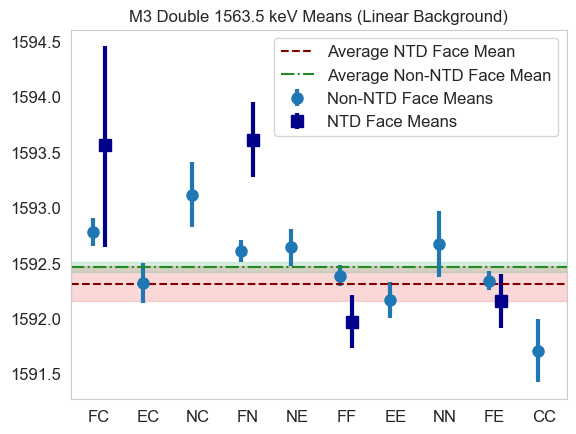

In [33]:
topologiesNTD = ['FC','FN','FF','FE']
NTDmeans = [FCmu_fitNTD, FNmu_fitNTD, FFmu_fitNTD, FEmu_fitNTD]

topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

mu_intersections = [FCintersection_mu,  CEintersection_mu, 
                     NCintersection_mu,  
                     [FNintersection_mu.geoms[0].x,FNintersection_mu.geoms[1].x],  
                    [NEintersection_mu.geoms[0].x,NEintersection_mu.geoms[1].x], 
                    [FFintersection_mu.geoms[0].x,FFintersection_mu.geoms[1].x],  
                    EEintersection_mu,
                   NNintersection_mu,  [FEintersection_mu.geoms[0].x,FEintersection_mu.geoms[1].x], CCintersection_mu ]

nonNTDmeans = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit, CCmu_fit]

asymmetric_errormu = Errors(mu_intersections, nonNTDmeans)


mu_intersectionsNTD = [FCintersection_muNTD,
                     FNintersection_muNTD, 
                    FFintersection_muNTD, 
                       FEintersection_muNTD]

ass_errNTD = Errors(mu_intersectionsNTD, NTDmeans)

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.12, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, nonNTDmeans, yerr=asymmetric_errormu, transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
ax.errorbar(topologiesNTD, NTDmeans, yerr=ass_errNTD, transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

ax.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')

ax.axhspan(NonNTDintersection_mu.geoms[0].x, NonNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(mu_fitNonNTD, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 1563.5 keV Means (Linear Background)')

Text(0.5, 1.0, 'M3 Double 1563.5 keV Standard Dev. (Linear Background)')

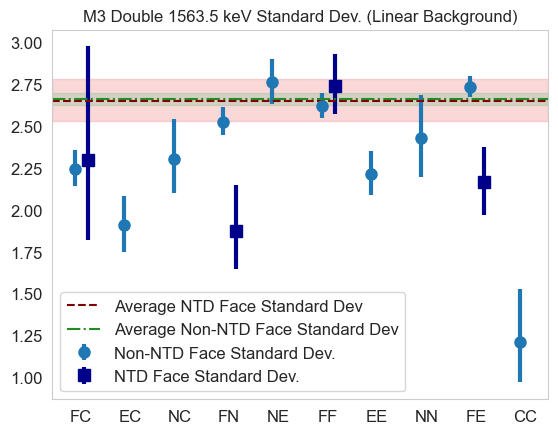

In [34]:
topologiesNTD = ['FC','FN','FF','FE']
NTDsds = [FCsigma_fitNTD, FNsigma_fitNTD, FFsigma_fitNTD, FEsigma_fitNTD]

topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

sigma_intersections = [[FCintersection_sigma.geoms[0].x,FCintersection_sigma.geoms[1].x],  [CEintersection_sigma.geoms[0].x,CEintersection_sigma.geoms[1].x], 
                     [NCintersection_sigma.geoms[0].x,NCintersection_sigma.geoms[1].x],  
                     [FNintersection_sigma.geoms[0].x,FNintersection_sigma.geoms[1].x],  
                    [NEintersection_sigma.geoms[0].x,NEintersection_sigma.geoms[1].x], 
                    [FFintersection_sigma.geoms[0].x,FFintersection_sigma.geoms[1].x],  
                    [EEintersection_sigma.geoms[0].x,EEintersection_sigma.geoms[1].x],
                   [NNintersection_sigma.geoms[0].x,NNintersection_sigma.geoms[1].x],  [FEintersection_sigma.geoms[0].x,FEintersection_sigma.geoms[1].x], 
                    [CCintersection_sigma.geoms[0].x,CCintersection_sigma.geoms[1].x]]

nonNTDsds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit, CCsigma_fit]


asymmetric_errorsigma = Errors(sigma_intersections, nonNTDsds)


sigma_intersectionsNTD = [[FCintersection_sigmaNTD.geoms[0].x,FCintersection_sigmaNTD.geoms[1].x],
                     [FNintersection_sigmaNTD.geoms[0].x,FNintersection_sigmaNTD.geoms[1].x], 
                    [FFintersection_sigmaNTD.geoms[0].x,FFintersection_sigmaNTD.geoms[1].x], 
                       [FEintersection_sigmaNTD.geoms[0].x,FEintersection_sigmaNTD.geoms[1].x]]

ass_errNTDsigma = Errors(sigma_intersectionsNTD, NTDsds)


fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.15, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, nonNTDsds, yerr=asymmetric_errorsigma,transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Dev.')
ax.errorbar(topologiesNTD, NTDsds, yerr=ass_errNTDsigma, fmt='s',ms=8,transform=trans2, elinewidth=3, color='darkblue', label='NTD Face Standard Dev.')

ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Standard Dev')

ax.axhspan(NonNTDintersection_sigma.geoms[0].x, NonNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(sigma_fitNonNTD, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev')

ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
ax.grid(False)
ax.set_title('M3 Double 1563.5 keV Standard Dev. (Linear Background)')

In [39]:
for i in range(len(nonNTDsds)):
    print(topologiesNonNTD[i]+ str(nonNTDsds[i]) + '-' + str(asymmetric_errorsigma[0][i]) + '+' + str(asymmetric_errorsigma[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(sigma_fitNonNTD)
print(sigma_fitNonNTD - NonNTDintersection_sigma.geoms[0].x)
print(sigma_fitNonNTD - NonNTDintersection_sigma.geoms[1].x)

for i in range(len(NTDsds)):
    print(str(NTDsds[i]) + '-' + str(ass_errNTDsigma[0][i]) + '+' + str(ass_errNTDsigma[1][i]))

FC2.247390917660004-0.10225606620266081+0.10818769161197661
EC1.907472957172795-0.16067174161050968+0.17749587501081
NC2.3066995358244453-0.20519690654422273+0.2347300889198305
FN2.5281802860770126-0.08099601328054806+0.08450637358617907
NE2.7628437332827662-0.12864965630387726+0.13714125303789215
FF2.623923913159665-0.07379580480807713+0.07706378771552957
EE2.216241584383046-0.12450032248729448+0.13576963065485526
NN2.4326030508184946-0.23333711464551454+0.2567184105330762
FE2.736194947874343-0.06265001907302992+0.06519615440859505
CC1.213841084234736-0.244691836405048+0.31316021576441955
2.6524929340700534
-0.12861926694583303
0.12006760616807055
2.664491888787031
-0.03594482425415091
0.03527082830205952
2.3002733271192675-0.4805784462642302+0.6768373828678063
1.8770083515958484-0.2309689291843382+0.27364441271403495
2.7433161806138893-0.17138332964630676+0.18780826324985833
2.1688322928122945-0.19766077391534842+0.21030363526659546


In [38]:
for i in range(len(nonNTDmeans)):
    print(topologiesNonNTD[i]+str(nonNTDmeans[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

print(mu_fitNonNTD)
print(mu_fitNonNTD - NonNTDintersection_mu.geoms[0].x)
print(mu_fitNonNTD - NonNTDintersection_mu.geoms[1].x)

for i in range(len(NTDmeans)):
    print(str(NTDmeans[i]) + '-' + str(ass_errNTD[0][i]) + '+' + str(ass_errNTD[1][i]))

FC1592.7775697763302-0.12551255125504213+0.12551255125504213
EC1592.3156816474998-0.18101810181019573+0.18101810181019573
NC1593.1170859532829-0.2902902902903861+0.2902902902903861
FN1592.6090082338728-0.10129004227314908+0.10124621547879542
NE1592.6393430972012-0.16632475172673367+0.16626363609088912
FF1592.3833258719987-0.095825819897982+0.09577462588526942
EE1592.1617944111335-0.16410940627088166+0.16410940627088166
NN1592.6665885538896-0.2976488244121356+0.2976488244121356
FE1592.3387816742352-0.08586387108448434+0.08586202821948064
CC1591.7073218493283-0.28734810578976067+0.28448892065762266
1592.3120433433874
0.15738537099969108
-0.15715963550701417
1592.464888997867
0.04421172305228538
-0.04412497409248317
1593.5679013187473-0.925925925925867+0.8858858858859548
1593.611554937846-0.3393393393394035+0.34034034034038996
1591.968810825064-0.23682454969980427+0.23682454969980427
1592.154862862878-0.24131032758191395+0.24131032758191395
